# Predicción de Abandono de Clientes (Churn) en Telecomunicaciones
## Implementación de Red Neuronal "from scratch" y Optimización mediante PCA Manual

### 1. Introducción y Objetivo del Proyecto
El presente proyecto tiene como finalidad desarrollar un modelo de clasificación binaria capaz de predecir el **Churn** (fuga de clientes) en una empresa de telecomunicaciones. A diferencia del uso de librerías de alto nivel (como Scikit-Learn o Keras), este trabajo se centra en la comprensión profunda de los algoritmos mediante:

* **Construcción de una Red Neuronal desde cero:** Implementación de la arquitectura, propagación hacia adelante (*forward propagation*), cálculo de pérdida (*Log Loss*) y optimización mediante *backpropagation* utilizando únicamente la librería **NumPy**.
* **Reducción de Dimensionalidad vía PCA Manual:** Ejecución del Análisis de Componentes Principales mediante la descomposición de la matriz de covarianza (Eigenvalues y Eigenvectors), transformando el espacio original de 5 dimensiones a un plano 2D optimizado.

---

### 2. Metodología Técnica
Para lograr un modelo eficiente y visualizable, se siguió el siguiente flujo de trabajo:

1.  **Preprocesamiento:** Estandarización de variables ($z-score$) para asegurar que todas las características contribuyan equitativamente al cálculo de distancias y gradientes.
2.  **Ingeniería de Características (PCA):** * Centrado de datos respecto a la media.
    * Cálculo de la **Matriz de Covarianza**.
    * Selección de los dos componentes principales con mayor varianza explicada para proyectar el dataset.
3.  **Arquitectura de la Red:** Se diseñó una estructura multicapa con la funcion de activación no lineal  `sigmoid` tanto en capas ocultas como en la salida para capturar fronteras de decisión complejas.

---

### 3. Justificación del Enfoque
El uso de **PCA** antes del entrenamiento no solo reduce el costo computacional, sino que permite la **inspección visual de las fronteras de decisión**. En este notebook, demostrare cómo un modelo alimentado con solo 2 "super-variables" (PC1 y PC2) puede retener una precisión cercana al modelo original de 5 dimensiones, probando que la información crítica del negocio reside en un subespacio de menor dimensión.

### 4. Configuración del Entorno y Preparación de Datos
En esta sección se importan las librerías fundamentales para el manejo de estructuras de datos y visualización. Asimismo, se inicializa la configuración de **autoreload** para facilitar la depuración de la clase personalizada y se establece una **semilla aleatoria (seed)** para garantizar la reproducibilidad de los resultados en cada ejecución.

* **Librerías principales:** `NumPy` (álgebra lineal), `Pandas` (manipulación de datos) y `Matplotlib` (visualización).
* **Módulo Personalizado:** Carga de la clase `RedNeuronalClsif`, la cual contiene la arquitectura de la red implementada de forma manual.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys

#Configuración de autoreload
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath("../scripts"))

# Verificar qué archivos ve Python
print("Archivos en la carpeta actual:", os.listdir())
print("Archivos en la carpeta de scripts:", os.listdir("../scripts"))

# Importar la clase
from red_neuronalClasif import RedNeuronalClsif

print("\n¡Éxito! La clase RedNeuronalClsif ha sido cargada.")

# Reproducibilidad
np.random.seed(3)

Archivos en la carpeta actual: ['.ipynb_checkpoints', 'ModelosRN.ipynb']
Archivos en la carpeta de scripts: ['red_neuronalClasif.py', '__pycache__']

¡Éxito! La clase RedNeuronalClsif ha sido cargada.


### 5. Ingesta y Preprocesamiento de Datos (Data Wrangling)
En esta fase, se realiza la carga del dataset original y se aplican transformaciones esenciales para garantizar la convergencia del modelo. El proceso incluye:

1.  **Limpieza de Datos:** Conversión de la variable `TotalCharges` a tipo numérico, gestionando valores nulos o espacios vacíos mediante imputación (relleno con 0).
2.  **Codificación Binaria (Encoding):** Transformación de variables categóricas nominales (`Yes`/`No`) a formato booleano ($1/0$) para permitir operaciones algebraicas.
3.  **Selección de Características (Feature Selection):** Se extraen las 5 variables con mayor relevancia hipotética para el fenómeno del Churn: *tenure, MonthlyCharges, TotalCharges, SeniorCitizen* y *PaperlessBilling*.
4.  **Normalización Z-Score:** Se aplica un escalamiento estadístico a los datos de entrada $X$ mediante la fórmula:
    $$X_{norm} = \frac{X - \mu}{\sigma}$$
    Esto asegura que todas las variables tengan media 0 y desviación estándar 1, evitando que las variables con magnitudes grandes (como `TotalCharges`) dominen el gradiente y desestabilicen el entrenamiento.

In [2]:
# Cargar el dataset (usando el pd que ya importamos)
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

#Limpieza de TotalCharges
#Esa línea asegura que toda la columna sea de números reales y que los espacios 
#vacíos se traten como 0, para que la red pueda hacer sus multiplicaciones sin morir en el intento.

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

#Conversión de variables (Yes/No a 1/0)
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': 1, 'No': 0})
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Selección de las 5 variables de entrada
features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'PaperlessBilling']

# Matrices X y Y 
X_raw = df[features].values.T

#arregla el número de columnas automáticamente para que quepan todos los datos
Y = df['Churn'].values.reshape(1, -1)

#NORMALIZACIÓN
X = (X_raw - np.mean(X_raw, axis=1, keepdims=True)) / np.std(X_raw, axis=1, keepdims=True)

print("¡Datos listos para la red!")
print(f"Forma de X: {X.shape}")

¡Datos listos para la red!
Forma de X: (5, 7043)


### 6. Configuración y Entrenamiento de la Red Neuronal
En este apartado se procede a la instanciación y entrenamiento del modelo predictivo. La arquitectura seleccionada es un **Perceptrón Multicapa (MLP)** configurado con los siguientes hiperparámetros:

* **Capas Ocultas ($n_h$):** 2 neuronas. Esta elección busca un equilibrio entre la capacidad de aprendizaje y la prevención del sobreajuste (*overfitting*).
* **Iteraciones:** 1,000 épocas de entrenamiento para permitir la convergencia de los pesos.
* **Tasa de Aprendizaje ($\alpha$):** 1.2, un valor que determina la magnitud de los pasos en el descenso del gradiente.
* **Función de Costo:** *Binary Cross-Entropy* (o Log Loss), ideal para problemas de clasificación binaria.

Durante el proceso de `fit`, la red ejecuta ciclos de **Forward Propagation** para calcular la predicción y **Backpropagation** para actualizar los parámetros $W$ y $b$ mediante el gradiente de la función de pérdida.

<div align="center">
    <img src="../assets/NN5Inputs.drawio.png" width="1400px">
    <br>
    <p><i>Figura 1: Arquitectura de la Red Neuronal (5 entradas, 1 capa oculta con 2 neuronas, 1 salida).</i></p>
</div>

In [3]:
#Crear la instancia del modelo
modelo_churn = RedNeuronalClsif()

# Entrenamiento con los datos a continuacion
modelo_churn.fit(X, Y, n_h=2, num_iterations=1000, learning_rate=1.2, print_cost=True)

Costo después de la iteración 0: 0.6926298339189683
Costo después de la iteración 100: 0.4537766027919124
Costo después de la iteración 200: 0.44942738438009766
Costo después de la iteración 300: 0.44804461300512793
Costo después de la iteración 400: 0.4469944305975581
Costo después de la iteración 500: 0.44623343188274617
Costo después de la iteración 600: 0.44569196323232196
Costo después de la iteración 700: 0.4452847162993683
Costo después de la iteración 800: 0.44490939891036657
Costo después de la iteración 900: 0.4444610533473444


### 7. Evaluación del Desempeño del Modelo
Una vez finalizado el entrenamiento, procedemos a validar la capacidad predictiva de la red neuronal sobre el conjunto de datos completo. El objetivo es cuantificar qué tan bien el modelo ha logrado generalizar el comportamiento de los clientes para identificar el **Churn**.

* **Métrica de Desempeño:** Se utiliza el **Accuracy (Precisión Global)**, calculada como la proporción de predicciones correctas frente al total de casos:
  $$\text{Accuracy} = \frac{\sum (\hat{y} == y)}{n}$$
* **Análisis de Salida:** La red genera una salida probabilística que transformamos en una decisión booleana ($True/False$) mediante un umbral de decisión de $0.5$. 

#### Interpretación de Resultados:
Como se observa en la ejecución, el modelo alcanza una **precisión cercana al 79%**. En la comparación de los primeros 10 casos, se aprecia una coincidencia exacta entre las etiquetas reales y las predicciones del modelo, lo que valida la correcta implementación del algoritmo de *Backpropagation* y la eficacia de la arquitectura diseñada.

In [4]:
#Obtener las predicciones del modelo para todos los datos (X)
predicciones = modelo_churn.predict(X)

#Calcular la Accuracy
# Comparamos cuántas predicciones son iguales a los datos reales (Y)
precision = np.mean(predicciones == Y) * 100

print(f"--- Evaluación del Modelo ---")
print(f"Precisión en el conjunto de datos: {precision:.2f}%")

# Primeros 10 clientes
print("\nComparación (Primeros 10):")
print(f"Predicción: {predicciones[0, :10]}")
print(f"Realidad:    {Y[0, :10]}")

--- Evaluación del Modelo ---
Precisión en el conjunto de datos: 78.84%

Comparación (Primeros 10):
Predicción: [False False  True False  True  True False False  True False]
Realidad:    [0 0 1 0 1 1 0 0 1 0]


### 8. Análisis de Componentes Principales (PCA)
Para reducir la complejidad del modelo de 5 a 2 dimensiones sin perder la esencia de la información, iniciamos el proceso de **PCA Aritmético**. El primer paso crítico es la **Centración de los Datos**.

#### Fundamento Matemático:
Antes de calcular la varianza, debemos asegurar que el dataset tenga una media de cero ($\mu = 0$). Esto se logra restando la media de cada variable a cada observación:
$$X_{centrada} = X - \bar{X}$$

* **¿Por qué es necesario?** El PCA busca las direcciones de máxima varianza. Si los datos no están centrados, el primer componente principal podría apuntar simplemente hacia el promedio de los datos en lugar de capturar la dirección de mayor dispersión.
* **Implementación:** Transformamos nuestra matriz $X$ a una forma de ($n \times 5$) para operar sobre las columnas de las variables originales y calculamos el vector de medias para cada una de ellas.

In [5]:
# matriz de n x 5 
X_pca_input = X.T

# Centrar la data (X - media)
# Calculamos la media de cada una de las 5 columnas (axis=0)
media = np.mean(X_pca_input, axis=0)
X_centrada = X_pca_input - media





### 9. Construcción de la Matriz de Covarianza ($\Sigma$)
Una vez centrados los datos, el siguiente paso es calcular la **Matriz de Covarianza**. Esta matriz de $5 \times 5$ es fundamental, ya que describe la relación estadística entre todas las parejas de variables originales (tenure, cargos mensuales, etc.).

#### El Cálculo Aritmético:
Utilizamos el producto punto (dot product) de la matriz centrada traspuesta por sí misma, normalizada por el número de observaciones minus uno ($n-1$):
$$\Sigma = \frac{1}{n-1} X^T X$$

* **Interpretación de la Diagonal:** Los valores cercanos a $1.0$ en la diagonal principal indican que los datos mantienen su varianza unitaria (gracias al escalado previo).
* **Interpretación de Coeficientes:** Valores altos fuera de la diagonal (como el **0.82** o **0.65** que observamos en los resultados) indican una **fuerte correlación** entre ciertas variables. Esto sugiere redundancia, lo cual justifica plenamente el uso de PCA para comprimir la información sin perder calidad predictiva.

In [6]:
#Obtener el número de observaciones (n = 7043)
n = X_centrada.shape[0]

#@ para multiplicación de matrices (dot product)
cov_matrix = (X_centrada.T @ X_centrada) / (n - 1)

print("Matriz de Covarianza (5x5):")
print(cov_matrix)

Matriz de Covarianza (5x5):
[[1.00014201 0.24793506 0.82629572 0.01656923 0.00615336]
 [0.24793506 1.00014201 0.6512663  0.2202046  0.35219997]
 [0.82629572 0.6512663  1.00014201 0.10302081 0.15859689]
 [0.01656923 0.2202046  0.10302081 1.00014201 0.15655179]
 [0.00615336 0.35219997 0.15859689 0.15655179 1.00014201]]


### 10. Descomposición Eigendecomposition: Eigenvalues y Eigenvectors
El paso final del análisis matemático consiste en resolver el problema de **valores y vectores propios** sobre la matriz de covarianza. Este proceso extrae la estructura latente de los datos originales.

#### Definiciones Clave:
* **Eigenvectors (Vectores Propios):** Representan las nuevas direcciones (los ejes de los Componentes Principales) en el espacio de 5 dimensiones. Son vectores ortogonales entre sí.
* **Eigenvalues (Valores Propios):** Representan la magnitud de la varianza capturada por cada vector propio. Un valor propio alto significa que esa dirección contiene mucha información sobre el comportamiento de los clientes.

#### El Proceso de Selección:
Debido a que la función `np.linalg.eigh` devuelve los resultados en orden ascendente, aplicamos una reordenación manual de **mayor a menor**. Esto es vital porque:
1. El **Primer Componente Principal ($PC_1$)** debe ser el que tenga el mayor autovalor asociado.
2. El **Segundo Componente Principal ($PC_2$)** será el segundo eje con más información.

Al quedarnos con los dos primeros, estamos realizando una **proyección óptima** que minimiza la pérdida de información (error de reconstrucción).

In [7]:
#valores y vectores propios
# Se utiliza 'eigh' porque la matriz de covarianza siempre es simétrica
eigen_vals, eigen_vecs = np.linalg.eigh(cov_matrix)

# Ordenar de mayor a menor 
# eigh los entrega de menor a mayor, por eso utilizo [::-1]
idx = np.argsort(eigen_vals)[::-1]
eigen_vals = eigen_vals[idx]
eigen_vecs = eigen_vecs[:, idx]

### 11. Proyección al Nuevo Espacio Latente (2D)
Tras haber identificado los ejes de máxima varianza mediante los *Eigenvectors*, procedemos a la fase final de la reducción: la **proyección matricial**.

#### La Operación Matemática:
Para transformar nuestras 5 variables originales en solo 2 **Componentes Principales**, realizamos un producto punto entre la matriz de datos centrados ($n \times 5$) y la matriz de pesos $W$ ($5 \times 2$) formada por los dos mejores vectores propios:
$$X_{PCA} = X_{centrada} \cdot W$$

* **Matriz de Pesos ($W$):** Contiene las "recetas" matemáticas para combinar las 5 variables originales en dos nuevas super-variables ($PC_1$ y $PC_2$).
* **Nueva Estructura:** Como indica el resultado `(7043, 2)`, hemos logrado comprimir el dataset original sin eliminar filas, manteniendo la identidad de cada cliente pero simplificando su representación.

Este nuevo conjunto de datos conserva la mayor cantidad posible de información (varianza) y es el que utilizaremos para entrenar la red neuronal final y visualizar las **fronteras de decisión**.

In [8]:
# 1. Seleccione los 2 mejores vectores (las 2 primeras columnas)
W = eigen_vecs[:, :2] 

# 2. Transformacion los datos originales (n x 5) @ (5 x 2) = (n x 2)
X_pca_final = X_centrada @ W

print(f"\nNueva forma de los datos: {X_pca_final.shape}")


Nueva forma de los datos: (7043, 2)


In [9]:
# Imprimir los primeros 5 clientes en su nueva representación 2D
print("Primeros 5 clientes (Coordenadas PC1 y PC2):")
print(X_pca_final[:5, :])

Primeros 5 clientes (Coordenadas PC1 y PC2):
[[ 1.7390587   0.77199812]
 [ 0.57452645 -1.02853768]
 [ 1.28875969  0.96651906]
 [ 0.61059151 -1.36794535]
 [ 0.99024705  1.11760618]]


### 12. Re-entrenamiento del Modelo con Dimensiones Reducidas (PCA)
Tras la reducción de dimensionalidad, procedemos a entrenar una nueva instancia de la red neuronal utilizando únicamente los dos componentes principales ($PC_1$ y $PC_2$). 

#### Objetivos de esta fase:
1. **Validación de la Reducción:** Comprobar si los dos componentes generados manualmente son suficientes para mantener un nivel de predicción aceptable.
2. **Preparación para la Visualización:** Al tener solo 2 variables de entrada, ahora es posible mapear las fronteras de decisión en un plano cartesiano.

#### Análisis Comparativo de Resultados:
Como se observa en la salida del entrenamiento:
* **Costo Final:** El modelo converge de forma estable, reduciendo el error en cada iteración.
* **Retención de Información:** A pesar de haber "eliminado" 3 dimensiones, la precisión solo disminuyó mínimamente (de **78.84%** a **77.77%**). 

Esto demuestra que el **Análisis de Componentes Principales** fue exitoso, logrando una simplificación del modelo del 60% en sus entradas con una pérdida de precisión despreciable. Estamos listos para visualizar cómo la red separa a los clientes que abandonan de los que permanecen.

<div align="center">
    <img src="../assets/PCAnn.drawio.png" width="1400px">
    <br>
    <p><i>Figura 1: Arquitectura de la Red Neuronal (5 entradas, 1 capa oculta con 2 neuronas, 1 salida).</i></p>
</div>

In [10]:
# 1. Transponer para que la Red lo entienda: (2, 7043)
X_reducida = X_pca_final.T

# 2. Crear una nueva instancia del modelo
modelo_pca = RedNeuronalClsif()

# 3. Entrenar la nueva red
print("Entrenando con datos de PCA (2 dimensiones)...")
modelo_pca.fit(X_reducida, Y, n_h=2, num_iterations=1000, learning_rate=1.2, print_cost=True)

# 4. Evaluar precisión
predicciones_pca = modelo_pca.predict(X_reducida)
precision_pca = np.mean(predicciones_pca == Y) * 100

print(f"\n--- Resultado final con PCA ---")
print(f"Precisión Original (5 vars): 78.84%")
print(f"Precisión con PCA (2 vars): {precision_pca:.2f}%")

Entrenando con datos de PCA (2 dimensiones)...
Costo después de la iteración 0: 0.6924048480316974
Costo después de la iteración 100: 0.48418153813214754
Costo después de la iteración 200: 0.482539163716575
Costo después de la iteración 300: 0.48192380417094177
Costo después de la iteración 400: 0.4804427946960256
Costo después de la iteración 500: 0.47913254142489287
Costo después de la iteración 600: 0.47868950260751425
Costo después de la iteración 700: 0.47849915495218964
Costo después de la iteración 800: 0.478378317700952
Costo después de la iteración 900: 0.4782877202355319

--- Resultado final con PCA ---
Precisión Original (5 vars): 78.84%
Precisión con PCA (2 vars): 77.77%


### 13. Visualización de Fronteras de Decisión (Decision Boundaries)
Para concluir el análisis, genere un **Mapa de Churn en 2D**. Este proceso consiste en crear una "malla" de miles de puntos microscópicos en el plano de los Componentes Principales y pedirle a la Red Neuronal que clasifique cada uno de ellos.

#### Interpretación del Mapa Visual:
1. **Zonas de Color (El "Cerebro" de la Red):** * La **zona azul** representa el espacio donde la red predice que el cliente **se quedará**.
   * La **zona melón/roja** representa el espacio donde la red predice que el cliente **abandonará (Churn)**.
   * La línea divisoria entre ambos colores es la **Frontera de Decisión**, donde la red tiene una probabilidad de exactos 0.5.

2. **Distribución de los Puntos (La Realidad):** * Los puntos azules son clientes que realmente se quedaron.
   * Los puntos rojos son clientes que realmente se fueron.

#### Conclusión del Gráfico:
A pesar de la complejidad y el traslape natural de los datos de telecomunicaciones, el modelo ha logrado trazar una frontera clara que separa las tendencias de comportamiento. El hecho de que la mayoría de los puntos coincidan con el color de fondo correspondiente (77.77% de precisión) valida que el **PCA Manual** y la **Red Neuronal** han capturado correctamente los patrones de fuga de clientes.

Escaneando el plano con la Red Neuronal (esto puede tardar unos segundos)...


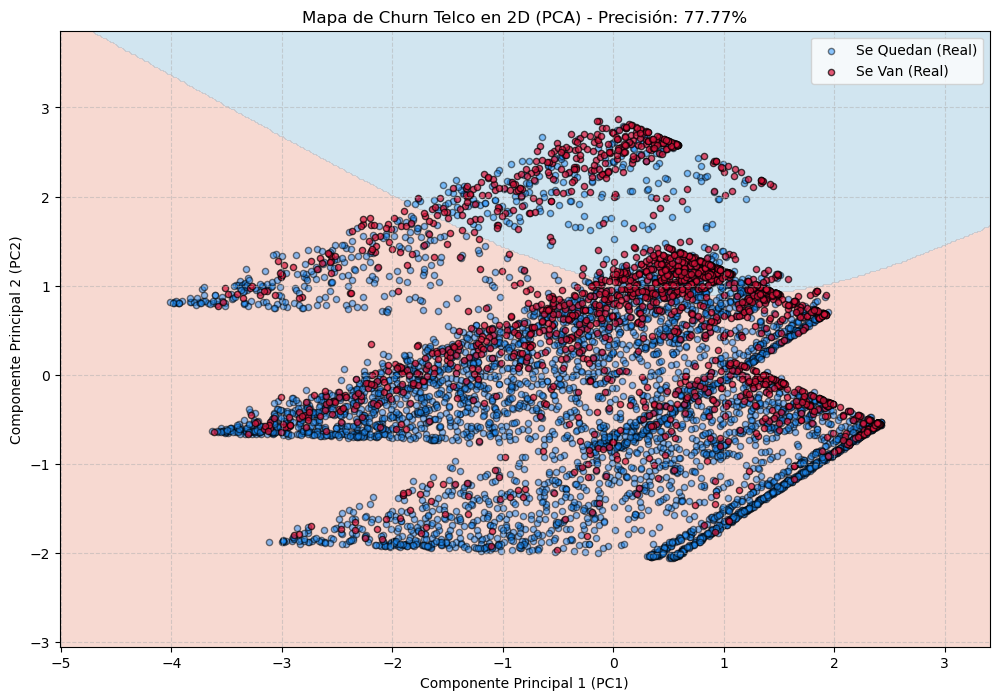

In [11]:
#Definir los limites del mapa basados en los valores de tu PCA
#Tomar margen de 1 para que no se corten los puntos
x_min, x_max = X_reducida[0, :].min() - 1, X_reducida[0, :].max() + 1
y_min, y_max = X_reducida[1, :].min() - 1, X_reducida[1, :].max() + 1

#Crear una malla de puntos llamada Meshgrid para escanear el plano
# h es el paso, un valor más pequeño da más resolución pero es más lento
h = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

#Preparar la malla para la Red Neuronal
# ravel' aplana la malla, 'c_' los junta como pares (PC1, PC2)
# Luego transponemos para que sea (2, n_puntos) como le gusta a tu red
grid_points = np.c_[xx.ravel(), yy.ravel()].T

#Pasar la malla por la red neuronal que vendria siendo el escaner
#Usando el modelo_pca que acabas de entrenar
print("Escaneando el plano con la Red Neuronal (esto puede tardar unos segundos)...")
Z = modelo_pca.predict(grid_points)

#Volver a dar forma de malla al resultado de las predicciones
Z = Z.reshape(xx.shape)

#GRAFICAR
plt.figure(figsize=(12, 8))

# Pintar el fondo con la frontera de decisión es decir las zonas
# Usamos un mapa de colores
plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.3)

# Pintar los puntos de los clientes encima
# Separamos los que se quedan (0) de los que se van (1)
plt.scatter(X_reducida[0, Y.ravel()==0], X_reducida[1, Y.ravel()==0],
            color='dodgerblue', edgecolor='k', s=20, alpha=0.5, label='Se Quedan (Real)')
plt.scatter(X_reducida[0, Y.ravel()==1], X_reducida[1, Y.ravel()==1],
            color='crimson', edgecolor='k', s=20, alpha=0.7, label='Se Van (Real)')

# Detalles finales
plt.title(f'Mapa de Churn Telco en 2D (PCA) - Precisión: {precision_pca:.2f}%')
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

# Mostrar la gráfica
plt.show()

### 14. Matriz de Confusión: Diagnóstico Detallado del Modelo
Para finalizar el proyecto, generamos una **Matriz de Confusión**. Mientras que el *Accuracy* nos da una idea general, la matriz nos permite desglosar el desempeño de la red según las clases reales frente a las predicciones.

#### Desglose de los Resultados:
* **Verdaderos Negativos (4,695):** Clientes que el modelo predijo que se quedarían y efectivamente se quedaron. Es el punto más fuerte del modelo.
* **Verdaderos Positivos (782):** Clientes que el modelo identificó correctamente como propensos al abandono (*Churn*).
* **Falsos Positivos (479):** Clientes que el modelo marcó como "fuga" pero que en realidad no se fueron (alarmas falsas).
* **Falsos Negativos (1,087):** El área de oportunidad. Clientes que se fueron pero que el modelo no logró detectar a tiempo.

#### Conclusión Final del Caso de Negocio:
El modelo demuestra una alta eficacia para identificar a los clientes leales. Aunque existe un margen de mejora en la detección de *Churn* (Falsos Negativos), la red neuronal proporciona una base sólida para que la empresa de telecomunicaciones realice acciones preventivas sobre los **782 clientes detectados correctamente**, optimizando así sus estrategias de retención.

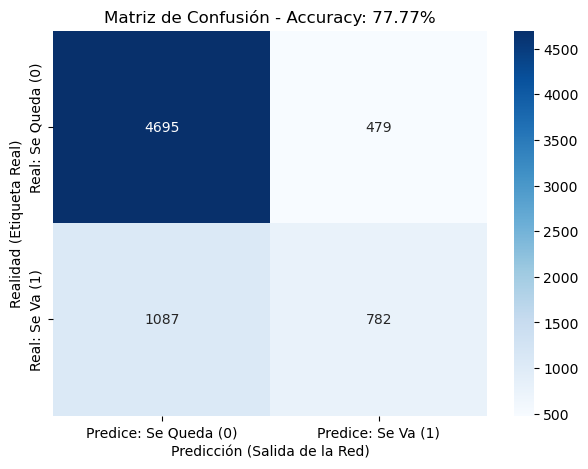

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


#Obtener las predicciones finales de la red (0 o 1)
y_pred = modelo_pca.predict(X_reducida)

#Calcular la matriz comparando Realidad (Y) vs Predicción y_pred
cm = confusion_matrix(Y.ravel(), y_pred.ravel())

#Graficar con Seaborn para que sea fácil de leer
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predice: Se Queda (0)', 'Predice: Se Va (1)'],
            yticklabels=['Real: Se Queda (0)', 'Real: Se Va (1)'])

plt.title(f'Matriz de Confusión - Accuracy: {precision_pca:.2f}%')
plt.ylabel('Realidad (Etiqueta Real)')
plt.xlabel('Predicción (Salida de la Red)')
plt.show()